In [1]:
import os
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
%matplotlib inline
from IPython.display import clear_output
import tqdm 
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

# data_folder = "drive/MyDrive/mestrado_final_files/data/"
# models_folder = "drive/MyDrive/mestrado_final_files/models/NGramModel_ExtraInfo/"

data_folder = "G:\Meu Drive\mestrado_final_files\data\\"
final_simulations_folder = "G:\Meu Drive\mestrado_final_files\simulations\\FinalSimulations\\"
models_token_folder = "G:\Meu Drive\mestrado_final_files\models\\NGramModel_ExtraInfo\\"
models_time_folder = "G:\Meu Drive\mestrado_final_files\models\\SpentTimeModel\\"


In [2]:
tokens_info = pd.read_csv(data_folder + 'tokens_info.txt', sep = ';')\
.sort_values(['cod', 'token'])\
.set_index('token')

# Convert the index of tokens_info to a list of tokens
list_tokens = tokens_info.index.to_list()

# Create a dictionary mapping each token to a unique integer, starting from 1
token_to_integer = {tok: idx + 1 for idx, tok in enumerate(list_tokens)}

# Assign a special integer (0) for the period (.)
token_to_integer['.'] = 0

# Create an inverse mapping from integers back to tokens
integer_to_token = {idx: tok for tok, idx in token_to_integer.items()}

# tokens_info = tokens_info\
# .query("hpts != 0 or vpts != 0 or limhteam != 0 or limvteam != 0")\
# .to_dict(orient = 'index')


In [3]:
def cria_colunas(dataframe):
    return dataframe\
    .assign(token_ = lambda df: df["token"].map(integer_to_token))\
    .assign(token_obj = lambda df: df["token"].map(integer_to_token))\
    .assign(token_obj = lambda df: df["token_obj"].str.replace("p..._8\(.+?\)", "", regex = True))\
    .assign(token_obj = lambda df: df["token_obj"].str.replace("p..._9\(.+?\)", "", regex = True))\
    .assign(token_obj = lambda df: df["token_obj"].str.replace("p..._18\(.+?\)", "", regex = True))\
    .assign(dif = lambda df: df["home_points"] - df["away_points"])\
    .assign(tk_simp = lambda df: df["token_obj"].str.replace("p...", "", regex = True).str.replace("\(.+?\)", "", regex = True))\
    .assign(n = lambda df: np.where(df["tk_simp"] == "", 1000000, df["step"]))\
    .assign(min_step = lambda df: df.groupby(["sim_id", "period", "remaining_time"])["n"].transform("min"))\
    .assign(n = lambda df: np.where(df["tk_simp"] == "", 0, df["step"]))\
    .assign(max_step = lambda df: df.groupby(["sim_id", "period", "remaining_time"])["n"].transform("max"))\
    .drop(columns = "n")\
    .query("tk_simp != ''")\
    .assign(next_token_obj = lambda df: df.groupby(["sim_id", "period"])["token_obj"].shift(-1).fillna(""))\
    .assign(last_token_obj = lambda df: df.groupby(["sim_id", "period"])["token_obj"].shift(1).fillna(""))

def coloca_posse_bola(dataframe):
    return dataframe\
    .assign(posse = 0)\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["token_obj"].str.contains("p[24].._4\(0.\)$")), -1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["token_obj"].str.contains("p[35].._4\(0.\)$")), 1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["token_obj"].str.contains("p2.._4\(1.\)$")), 1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["token_obj"].str.contains("p3.._4\(1.\)$")), -1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["token_obj"].str.contains("p4.._2\(.+?\)$")), 1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["token_obj"].str.contains("p5.._2\(.+?\)$")), -1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["token_obj"].str.contains("p4.._1\(.+?\)$")), 1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["token_obj"].str.contains("p5.._1\(.+?\)$")), -1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["token_obj"].str.contains("p4.._6\([12].+?\)$")), -1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["token_obj"].str.contains("p5.._6\([12].+?\)$")), 1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["token_obj"].str.contains("p[246].._6\(0.+?\)$")), -1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["token_obj"].str.contains("p[357].._6\(0.+?\)$")), 1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["token_obj"].str.contains("p[24].._5\(.+?\)$")), 1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["token_obj"].str.contains("p[35].._5\(.+?\)$")), -1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["token_obj"].str.contains("p4.._3\(.+?\)$")), 1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["token_obj"].str.contains("p5.._3\(.+?\)$")), -1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["token_obj"].str.contains("p4.._7\(5p\)$")), -1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["token_obj"].str.contains("p5.._7\(5p\)$")), 1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["token_obj"].str.contains("p000_12\([234]\)")), df["ball_possession"], df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["token_obj"].str.contains("p000_12\(0\)p45[02345]_10\(0\)")), 3, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["token_obj"].str.contains("p000_12\(1\)p45[02345]_10\(0\)")), 3, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["token_obj"].str.contains("p000_12\(0\)")), 3, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["token_obj"].str.contains("p000_12\(1\)")), 3, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["token_obj"].str.contains("^p000_13\(.\)$")) & (df["last_token_obj"].str.contains('p[24].._4\(.+?\)')), 1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["token_obj"].str.contains("^p000_13\(.\)$")) & (df["last_token_obj"].str.contains('p[35].._4\(.+?\)')), -1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["token_obj"].str.contains("^p000_13\(.\)$")) & (df["last_token_obj"].str.contains('p4.._1\(.+?\)')), -1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["token_obj"].str.contains("^p000_13\(.\)$")) & (df["last_token_obj"].str.contains('p5.._1\(.+?\)')), 1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["token_obj"].str.contains("^p000_13\(.\)$")) & (df["last_token_obj"].str.contains('p4.._3\(.+?\)')), -1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["token_obj"].str.contains("^p000_13\(.\)$")) & (df["last_token_obj"].str.contains('p5.._3\(.+?\)')), 1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["token_obj"].str.contains("^p000_13\(.\)$")) & (df["last_token_obj"].str.contains('p[24].._5\(.+?\)')), -1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["token_obj"].str.contains("^p000_13\(.\)$")) & (df["last_token_obj"].str.contains('p[35].._5\(.+?\)')), 1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["token_obj"].str.contains("^p000_13\(.\)$")) & (df["last_token_obj"].str.contains('p4.._6\(.+?\)')), -1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["token_obj"].str.contains("^p000_13\(.\)$")) & (df["last_token_obj"].str.contains('p5.._6\(.+?\)')), 1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["token_obj"].str.contains("^p000_13\(.\)$")) & (df["last_token_obj"].str.contains('p4.._7\(.+?\)')), -1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["token_obj"].str.contains("^p000_13\(.\)$")) & (df["last_token_obj"].str.contains('p5.._7\(.+?\)')), 1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["token_obj"].str.contains("^p000_13\(.\)$")) & (df["last_token_obj"].str.contains('p45[24]_10\(.+?\)')), 1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["token_obj"].str.contains("^p000_13\(.\)$")) & (df["last_token_obj"].str.contains('p45[35]_10\(.+?\)')), -1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["token_obj"].str.contains("^p000_13\(.\)$")), 4, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["token_obj"].str.contains("p45[2345]_10\([12]\)")), 5, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(5)) & (df["last_token_obj"].str.contains("p[24].._4\(.+?\)")), 1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(5)) & (df["last_token_obj"].str.contains("p[35].._4\(.+?\)")), -1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(5)) & (df["last_token_obj"].str.contains("p4.._2\(.+?\)")), -1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(5)) & (df["last_token_obj"].str.contains("p5.._2\(.+?\)")), 1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(5)) & (df["last_token_obj"].str.contains("p4.._1\(.+?\)")), -1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(5)) & (df["last_token_obj"].str.contains("p5.._1\(.+?\)")), 1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(5)) & (df["last_token_obj"].str.contains("p4.._5\(.+?\)")), 1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(5)) & (df["last_token_obj"].str.contains("p5.._5\(.+?\)")), -1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(5)) & (df["last_token_obj"].str.contains("p4.._6\(.+?\)")), -1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(5)) & (df["last_token_obj"].str.contains("p5.._6\(.+?\)")), 1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["next_token_obj"].str.contains("p4.._3\(.+?\)")), 1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["next_token_obj"].str.contains("p5.._3\(.+?\)")), -1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["tk_simp"].isin(["_6", "_10", "_11", "_12"])) & (df["next_token_obj"].str.contains("p4.._2\(.+?\)")), 1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["tk_simp"].isin(["_6", "_10", "_11", "_12"])) & (df["next_token_obj"].str.contains("p5.._2\(.+?\)")), -1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["tk_simp"].isin(["_6", "_10", "_12"])) & (df["next_token_obj"].str.contains("p4.._1\(.+?\)")), 1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["tk_simp"].isin(["_6", "_10", "_12"])) & (df["next_token_obj"].str.contains("p5.._1\(.+?\)")), -1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["tk_simp"].isin(["_6", "_10", "_12"])) & (df["next_token_obj"].str.contains("p[24].._5\(.+?\)")), 1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["tk_simp"].isin(["_6", "_10", "_12"])) & (df["next_token_obj"].str.contains("p[35].._5\(.+?\)")), -1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["tk_simp"].eq("_7")) & (df["next_token_obj"].str.contains("p4.._2\(.+?\)")), 1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["tk_simp"].eq("_7")) & (df["next_token_obj"].str.contains("p5.._2\(.+?\)")), -1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["tk_simp"].eq("_7")) & (df["next_token_obj"].str.contains("p4.._1\(.+?\)")), 1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["tk_simp"].eq("_7")) & (df["next_token_obj"].str.contains("p5.._1\(.+?\)")), -1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["tk_simp"].eq("_7")) & (df["next_token_obj"].str.contains("p4.._3\(.+?\)")), 1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["tk_simp"].eq("_7")) & (df["next_token_obj"].str.contains("p5.._3\(.+?\)")), -1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["tk_simp"].eq("_7")) & (df["next_token_obj"].str.contains("p[24].._5\(.+?\)")), 1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["tk_simp"].eq("_7")) & (df["next_token_obj"].str.contains("p[35].._5\(.+?\)")), -1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["tk_simp"].eq("_6")) & (df["next_token_obj"].str.contains("p[24].._6\([12]..\)")), 1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["tk_simp"].eq("_6")) & (df["next_token_obj"].str.contains("p[35].._6\([12]..\)")), -1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["tk_simp"].isin(["_7", "_12"])) & (df["next_token_obj"].str.contains("p4.._6\([12]..\)")), -1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["tk_simp"].isin(["_7", "_12"])) & (df["next_token_obj"].str.contains("p5.._6\([12]..\)")), 1, df["posse"]))\
    .assign(posse = lambda df: np.where(df["posse"].isin([0,4,5]), 1, df["posse"]))

def preenche_dataframe(df, df_full):
    return df_full\
    .merge(df, how = "left")\
    .assign(home_points = lambda df1: df1["home_points"].ffill())\
    .assign(away_points = lambda df1: df1["away_points"].ffill())\
    .assign(dif = lambda df1: df1["dif"].ffill())\
    .assign(posse = lambda df1: df1["posse"].bfill())

def define_resultado_final(df):
    return df\
    .assign(outcome = "draw")\
    .assign(outcome = lambda df1: np.where(df1["home_points"].max() > df1["away_points"].max(), "home", df1["outcome"]))\
    .assign(outcome = lambda df1: np.where(df1["home_points"].max() < df1["away_points"].max(), "away", df1["outcome"]))

def pre_process_dataframe(df):
    return df\
    .groupby("sim_id")\
    .apply(func = lambda df_: preenche_dataframe(df = df_, df_full = df_full), include_groups = False)\
    .reset_index()\
    .groupby("sim_id")\
    .apply(define_resultado_final, include_groups = False)\
    .reset_index("sim_id")\
    .assign(dif = lambda df1: np.where(df1["dif"] < -25, -25, df1["dif"]))\
    .assign(dif = lambda df1: np.where(df1["dif"] > 25, 25, df1["dif"]))\
    .groupby(["period", "remaining_time", "dif", "posse", "outcome"], as_index = False, dropna = False).size()

In [4]:
lista_tempo = list(np.arange(7200, 599, -10, dtype = int)) + list((np.arange(599, -1, -1)))
df_full = pd.DataFrame({
    "period": ([1] * 1261) + ([2] * 1261) + ([3] * 1261) + ([4] * 1261),
    "remaining_time": lista_tempo + lista_tempo + lista_tempo + lista_tempo})

## Agrega resultados simulações

In [92]:
for season in ['201819', '201920', '202021', '202122', '202223']:
    list_files_season = [item for item in os.listdir(final_simulations_folder) if season in item]
    
    for file in list_files_season:
        final_file = final_simulations_folder.replace("FinalSimulations", "Resultados_FinalSimulations") + file

        xdf = pd.read_parquet(final_simulations_folder + file)\
        .pipe(func = cria_colunas)\
        .query("step == max_step")\
        .pipe(func = coloca_posse_bola)

        df_final = pd.DataFrame()

        for id in tqdm.tqdm(np.arange(100)):
            df1 = xdf.query("(sim_id % 100) == @id")\
            .pipe(func = pre_process_dataframe)
            
            df_final = pd.concat([df_final, df1], axis = 0)\
            .groupby(["period", "remaining_time", "dif", "posse", "outcome"], as_index = False, dropna = False)["size"].sum()

        df_final.to_parquet(final_file)


100%|██████████| 100/100 [03:40<00:00,  2.21s/it]


In [5]:
dict_agregado = {}
for season in ['201819', '201920', '202021', '202122', '202223']:
    list_files_season = [item for item in os.listdir(final_simulations_folder) if season in item]
    print(season)
    df_agregado = pd.DataFrame()
    for file in tqdm.tqdm(list_files_season):
        final_file = final_simulations_folder.replace("FinalSimulations", "Resultados_FinalSimulations") + file

        df_parte = pd.read_parquet(final_file)

        df_agregado = pd.concat([df_agregado, df_parte], axis = 0)\
        .groupby(["period", "remaining_time", "dif", "posse", "outcome"], as_index = False, dropna = False)["size"].sum()

    dict_agregado[season] = df_agregado

201819


100%|██████████| 10/10 [00:10<00:00,  1.01s/it]


201920


100%|██████████| 10/10 [00:09<00:00,  1.00it/s]


202021


100%|██████████| 10/10 [00:09<00:00,  1.02it/s]


202122


100%|██████████| 10/10 [00:09<00:00,  1.03it/s]


202223


100%|██████████| 10/10 [00:09<00:00,  1.01it/s]


In [6]:
dict_agregado["201819"]

,period,remaining_time,dif,posse,outcome,size
0,1,0,-25.0,-1.0,away,66
1,1,0,-25.0,-1.0,home,1
2,1,0,-25.0,1.0,away,85
3,1,0,-25.0,1.0,home,4
4,1,0,-24.0,-1.0,away,26
...,...,...,...,...,...,...
1325232,4,7200,24.0,1.0,home,461
1325233,4,7200,25.0,-1.0,away,1
1325234,4,7200,25.0,-1.0,home,2639
1325235,4,7200,25.0,1.0,away,2


In [7]:
dict_agregado["201819"] = dict_agregado["201819"]\
.sort_values(["period", "remaining_time", "dif", "posse"], ascending = [True, False, True, True])\
.assign(total = lambda df: df.groupby(["period", "remaining_time", "dif", "posse"])["size"].transform("sum"))\
.assign(prop = lambda df: df["size"] / df["total"])\
.assign(ind_turning = lambda df: df["prop"] >= 0.95)\
.assign(ind_turning = lambda df: df.groupby(["period", "remaining_time", "dif", "posse"])["ind_turning"].transform("sum"))

In [8]:
dict_agregado["201920"] = dict_agregado["201920"]\
.sort_values(["period", "remaining_time", "dif", "posse"], ascending = [True, False, True, True])\
.assign(total = lambda df: df.groupby(["period", "remaining_time", "dif", "posse"])["size"].transform("sum"))\
.assign(prop = lambda df: df["size"] / df["total"])\
.assign(ind_turning = lambda df: df["prop"] >= 0.95)\
.assign(ind_turning = lambda df: df.groupby(["period", "remaining_time", "dif", "posse"])["ind_turning"].transform("sum"))

In [9]:
dict_agregado["202021"] = dict_agregado["202021"]\
.sort_values(["period", "remaining_time", "dif", "posse"], ascending = [True, False, True, True])\
.assign(total = lambda df: df.groupby(["period", "remaining_time", "dif", "posse"])["size"].transform("sum"))\
.assign(prop = lambda df: df["size"] / df["total"])\
.assign(ind_turning = lambda df: df["prop"] >= 0.95)\
.assign(ind_turning = lambda df: df.groupby(["period", "remaining_time", "dif", "posse"])["ind_turning"].transform("sum"))

In [10]:
dict_agregado["202122"] = dict_agregado["202122"]\
.sort_values(["period", "remaining_time", "dif", "posse"], ascending = [True, False, True, True])\
.assign(total = lambda df: df.groupby(["period", "remaining_time", "dif", "posse"])["size"].transform("sum"))\
.assign(prop = lambda df: df["size"] / df["total"])\
.assign(ind_turning = lambda df: df["prop"] >= 0.95)\
.assign(ind_turning = lambda df: df.groupby(["period", "remaining_time", "dif", "posse"])["ind_turning"].transform("sum"))

In [11]:
dict_agregado["202223"] = dict_agregado["202223"]\
.sort_values(["period", "remaining_time", "dif", "posse"], ascending = [True, False, True, True])\
.assign(total = lambda df: df.groupby(["period", "remaining_time", "dif", "posse"])["size"].transform("sum"))\
.assign(prop = lambda df: df["size"] / df["total"])\
.assign(ind_turning = lambda df: df["prop"] >= 0.95)\
.assign(ind_turning = lambda df: df.groupby(["period", "remaining_time", "dif", "posse"])["ind_turning"].transform("sum"))

In [14]:
dict_agregado["201819"]\
.to_parquet(final_simulations_folder.replace("FinalSimulations\\", "") + 'matrizes_probs_simulacoes_201819.parquet', index = False, compression = "zstd")

In [15]:
dict_agregado["201920"]\
.to_parquet(final_simulations_folder.replace("FinalSimulations\\", "") + 'matrizes_probs_simulacoes_201920.parquet', index = False, compression = "zstd")

In [16]:
dict_agregado["202021"]\
.to_parquet(final_simulations_folder.replace("FinalSimulations\\", "") + 'matrizes_probs_simulacoes_202021.parquet', index = False, compression = "zstd")

In [17]:
dict_agregado["202122"]\
.to_parquet(final_simulations_folder.replace("FinalSimulations\\", "") + 'matrizes_probs_simulacoes_202122.parquet', index = False, compression = "zstd")

In [18]:
dict_agregado["202223"]\
.to_parquet(final_simulations_folder.replace("FinalSimulations\\", "") + 'matrizes_probs_simulacoes_202223.parquet', index = False, compression = "zstd")

In [ ]:
# a partir daqui voce vai ter a posse
# mandante
['p550_1','p500_1', #1
 'p440_1p541_6','p400_1p541_6', #1_6
 'p500_1p200_9','p550_1p200_9', #1_9
 'p550_1p200_9p440_8', #1_9_8
 'p400_2p200_4', 'p400_2p400_4', 'p405_2p200_4', 'p405_2p400_4','p500_2p200_4', 'p500_2p400_4','p504_2p200_4','p504_2p400_4', #2_4
 'p400_2p200_4p541_6', # 2_4_6
 'p500_4p500_1', #4_1
 'p200_4', 'p400_4', #4
 'p200_4p550_8', 'p200_4p440_8',#4_8
 'p500_4p500_2p400_4', 'p400_4p400_2p400_4', # 4_2_4
 'p300_4p301_5', # 4_5
 'p200_4p541_6', 'p400_4p541_6', #4_6
 'p200_4p541_6p550_8', #4_6_8
 'p200_4p454_10', #4_10
 'p541_6p501_5', #6_5
 'p541_6p501_5p550_8', 'p541_6p501_5p440_8',#6_5_8
 'p541_6p501_5p440_8p550_8', 'p541_6p501_5p550_8p550_8', #6_5_8_8
 'p501_6','p541_6', 'p301_6', 'p701_6', #6
 'p541_6p440_8', 'p541_6p550_8', #6_8
 'p541_6p440_8p550_8', 'p541_6p550_8p550_8', 'p541_6p440_8p440_8',#6_8_8
 'p541_6p440_8p550_8p550_8','p541_6p440_8p440_8p550_8',#6_8_8_8
 'p541_6p001_18', #6_18
 'p452_10','p454_10', # 10
 'p454_10p540_5', #10_5
 'p000_12p454_10', #12_10
 ]
# visitante
['p440_1','p400_1', #1 
 'p500_1p451_6', 'p550_1p451_6',#1_6
 'p440_1p300_9',  'p400_1p300_9',# 1_9
 'p440_1p300_9p550_8',#1_9_8
 'p400_2p300_4', 'p400_2p500_4', 'p405_2p300_4','p405_2p500_4','p500_2p300_4', 'p500_2p500_4', 'p504_2p300_4', 'p504_2p500_4', #2_4
 'p500_2p300_4p451_6', #2_4_6
 'p400_4p400_1',  #4_1
 'p300_4', 'p500_4', #4
 'p300_4p440_8', 'p300_4p550_8', #4_8
 'p400_4p400_2p500_4', 'p500_4p500_2p500_4', #4_2_4
 'p200_4p201_5', #4_5
 'p300_4p451_6', 'p500_4p451_6', #4_6
 'p300_4p451_6p440_8', #4_6_8
 'p451_6p401_5',  #6_5
 'p451_6p401_5p440_8', 'p451_6p401_5p550_8', #6_5_8
 'p451_6p401_5p440_8p550_8',#6_5_8_8
 'p451_6','p401_6', 'p201_6','p601_6'# 6
 'p451_6p440_8', 'p451_6p550_8', #6_8
 'p451_6p440_8p550_8', 'p451_6p440_8p440_8','p451_6p550_8p550_8',#6_8_8
 'p451_6p440_8p440_8p550_8','p451_6p440_8p550_8p550_8', #6_8_8_8
 'p451_6p001_18', #6_18
 'p453_10','p455_10', #10
 'p455_10p450_5', #10_5
 'p000_12p455_10', #12_10
  ]

# voce tinha a posse quando isso aconteceu
# mandante
['p400_1p541_6p400_3', 'p440_1p541_6p400_3', #1_6_3
 'p440_1p541_6p550_8p400_3', #1_6_8_3
 'p400_2','p405_2',  #2
 'p400_2p200_4p000_13', #2_4_13
 'p400_3', #3
 'p550_8p400_3','p440_8p400_3',  #8_3
 'p440_8p550_8p400_3', 'p550_8p550_8p400_3', 'p440_8p440_8p400_3',#8_8_3 
 'p440_8p440_8p550_8p400_3', 'p440_8p550_8p550_8p400_3',#8_8_8_3 
 'p400_3p400_3', #3_3
 'p550_8p400_3p400_3', #8_3_3
 'p400_3p400_3p400_3', #3_3_3
 'p400_3p200_4', #3_4
 'p400_3p200_4p400_3', #3_4_3
 'p400_4p400_2', #4_2
 'p200_4p541_6p400_3', # 4_6_3
 'p400_4p541_6p400_3p400_3', 'p200_4p541_6p400_3p400_3', #4_6_3_3
 'p201_5', 'p401_5', 'p450_5', #5
 'p401_5p550_8','p401_5p440_8', #5_8
 'p541_6p400_3', 'p501_6p400_3', #6_3
 'p541_6p400_3p400_3', #6_3_3 
 'p541_6p400_3p440_8p400_3', 'p541_6p400_3p550_8p400_3',#6_3_8_3
 'p541_6p400_3p440_8p550_8p400_3','p541_6p400_3p550_8p550_8p400_3','p541_6p400_3p440_8p440_8p400_3',#6_3_8_8_3
 'p541_6p400_3p440_8p550_8p550_8p400_3',#6_3_8_8_8_3
 'p541_6p400_3p200_4', #6_3_4
 'p541_6p400_3p200_4p400_3', #6_3_4_3
 'p541_6p400_3p200_4p440_8p400_3','p541_6p400_3p200_4p550_8p400_3', #6_3_4_8_3
 'p541_6p400_3p400_3p400_3', #6_3_3_3

 ]
# visitante
['p500_1p451_6p500_3', 'p550_1p451_6p500_3', #1_6_3
 'p550_1p451_6p440_8p500_3', #1_6_8_3
 'p500_2','p504_2', #2
 'p500_4p500_2', #4_2
 'p500_2p300_4p000_13', #2_4_13
 'p500_3', #3
 'p440_8p500_3', 'p550_8p500_3', #8_3
 'p440_8p550_8p500_3', 'p440_8p440_8p500_3','p550_8p550_8p500_3',#8_8_3
 'p440_8p550_8p550_8p500_3','p440_8p440_8p550_8p500_3',#8_8_8_3
 'p500_3p500_3', #3_3
 'p440_8p500_3p500_3' #8_3_3
 'p500_3p300_4',#3_4
 'p500_3p300_4p500_3', #3_4_3
 'p500_3p500_3p500_3', #3_3_3
 'p300_4p451_6p500_3',#4_6_3
 'p300_4p451_6p500_3p500_3', 'p500_4p451_6p500_3p500_3',#4_6_3_3
 'p301_5', 'p501_5', 'p540_5', #5
 'p501_5p440_8','p501_5p550_8', # 5_8
 'p451_6p500_3', 'p401_6p500_3', # 6_3
 'p451_6p500_3p440_8p440_8', #6_3_8_8
 'p451_6p500_3p500_3', #6_3_3
 'p451_6p500_3p440_8p500_3', 'p451_6p500_3p550_8p500_3', #6_3_8_3
 'p451_6p500_3p550_8p550_8p500_3' # 6_3_8_8_3
 'p451_6p500_3p440_8p440_8p550_8p500_3', #6_3_8_8_8_3
 'p451_6p500_3p300_4', #6_3_4
 'p451_6p500_3p300_4p500_3', #6_3_4_3
 'p451_6p500_3p440_8p550_8p500_3', 'p451_6p500_3p440_8p440_8p500_3', #6_3_8_8_3
 'p451_6p500_3p300_4p440_8p500_3', 'p451_6p500_3p300_4p550_8p500_3', #6_3_4_8_3 
 'p451_6p500_3p500_3p500_3', # 6_3_3_3
 
 ]

# nao da pra saber
[
 'p201_7','p301_7', 'p501_7', 'p401_7', #7
 'p400_1p501_7','p500_1p401_7', 'p550_1p401_7', 'p440_1p501_7',#_1_7
 'p741_6', 'p651_6','p671_6', #6
 'p440_8', 'p550_8', #8
 'p440_8p440_8', 'p440_8p550_8','p550_8p550_8', 'p550_8p440_8', #8_8  
 'p440_8p550_8p550_8', 'p440_8p440_8p550_8', 'p550_8p550_8p550_8', 'p440_8p440_8p440_8', #8_8_8
 'p440_8p440_8p550_8p550_8', 'p440_8p550_8p550_8p550_8','p440_8p440_8p440_8p550_8', #8_8_8_8
 'p440_8p440_8p550_8p550_8p550_8','p440_8p440_8p440_8p550_8p550_8',#8_8_8_8_8
 'p200_9', 'p300_9',  #9 
 'p200_9p440_8', 'p200_9p550_8', 'p300_9p440_8','p300_9p550_8', #9_8
 'p200_9p440_8p440_8','p200_9p440_8p550_8','p200_9p550_8p550_8','p300_9p550_8p550_8','p300_9p440_8p550_8', 'p300_9p440_8p440_8', #9_8_8
 'p200_9p440_8p440_8p550_8','p200_9p440_8p440_8p440_8','p200_9p440_8p550_8p550_8','p300_9p440_8p550_8p550_8', 'p300_9p440_8p440_8p550_8', 'p300_9p550_8p550_8p550_8', #9_8_8_8
 'p200_9p440_8p440_8p550_8p550_8','p200_9p440_8p440_8p440_8p550_8','p300_9p440_8p440_8p550_8p550_8', 'p300_9p440_8p550_8p550_8p550_8', #9_8_8_8_8
 'p300_9p440_8p440_8p550_8p550_8p550_8', #9_8_8_8_8_8
 'p200_9p001_18', 'p300_9p001_18', #9_18
 'p401_11','p501_11','p701_11','p601_11', #11
 'p000_12', #12
 'p000_13', #13
 'p001_18', #18
 'p001_18p000_13', #18_13
]


 
 
 
 
 
 
 

## Calcula posse para partidas reais

In [5]:
def add_ball_possession(df):
    """
    This function calculates the first ball possession for each team based on specific
    game events. The possession is tracked throughout the game, including overtime periods.

    Parameters:
    -----------
    df : pandas.DataFrame
        The input DataFrame containing game events. It must include the columns 'game_id',
        'period', 'clock', and 'token'.

    Returns:
    --------
    df_modified : pandas.DataFrame
        The original DataFrame with an additional column 'ball_possession' that indicates the
        possession of the ball. Possession is 1 if the home team has the ball, -1 if the away
        team has the ball, and 0 if the possession is neutral or undefined.
    """

    # Tokens associated with the home team having possession
    home_possession_tokens = ['p000_12(1)p454_10(0)', 'p452_10(0)',
                              'p454_10(0)', 'p452_10(1)', 'p454_10(1)']

    # Tokens associated with the away team having possession
    away_possession_tokens = ['p000_12(1)p455_10(0)', 'p453_10(0)',
                              'p455_10(0)', 'p453_10(1)', 'p455_10(1)']

    # Step 1: Identify the initial possession at the start of period 1
    initial_possession = df\
    .query("period == 1 & clock == '12:00:00'")\
     [['game_id', 'period', 'clock', 'token']]\
    .assign(possession = lambda df: np.where(df["token"].isin(home_possession_tokens), 1, 0))\
    .assign(possession = lambda df: np.where(df["token"].isin(away_possession_tokens), -1, df["possession"]))\
    .query("possession != 0")\
    .drop_duplicates(['game_id'])

    # Step 2: Identify possession based on tokens following the initial possession
    following_possession = df\
    .merge(initial_possession[['game_id']].assign(aux = 1), how = 'left')\
    .query("aux != 1")\
    .assign(last_token = lambda x: x['token'].shift(1))\
    .query("last_token == 'p000_12(1)' & clock != '12:00:00'")\
    [['game_id', 'period', 'clock', 'token']]\
    .assign(possession = lambda df: np.where(df["token"].isin(home_possession_tokens), 1, 0))\
    .assign(possession = lambda df: np.where(df["token"].isin(away_possession_tokens), -1, df["possession"]))\
    .query("possession != 0")\
    .drop_duplicates(['game_id'])

    # Combine initial and following possessions
    combined_possession = pd.concat([initial_possession, following_possession])\
    .drop_duplicates(['game_id'])

    # Step 3: Capture possession changes that occur after the initial possession
    additional_possession = df\
    .merge(combined_possession[['game_id']].assign(aux = 1), how = 'left')\
    .query("aux != 1")\
    .assign(last_token = lambda x: x['token'].shift(1))\
    .query("last_token == 'p000_12(1)'")\
    [['game_id', 'period', 'clock', 'token']]\
    .assign(possession = lambda df: np.where(df["token"].isin(['p501_7(4p)']), 1, 0))\
    .assign(possession = lambda df: np.where(df["token"].isin(['p401_7(4p)']), -1, df["possession"]))\
    .query("possession != 0")\
    .drop_duplicates(['game_id'])

    # Combine with previous possessions
    combined_possession = pd.concat([combined_possession, additional_possession])\
    .drop_duplicates(['game_id'])

    # Step 4: Handle possession during overtime periods
    overtime_possession = df\
    .query("period == 5 & clock == '05:00:00'")\
    .assign(possession_ot = lambda df: np.where(df["token"].isin(['p454_10(0)', 'p452_10(0)']), 1, 0))\
    .assign(possession_ot = lambda df: np.where(df["token"].isin(['p455_10(0)', 'p453_10(0)']), -1, df["possession_ot"]))\
    .query("possession_ot != 0")\
    [['game_id', 'period', 'clock', 'token', 'possession_ot']]\
    .drop_duplicates(['game_id'])

    # Combine all possession data, including overtime
    combined_possession = pd.concat([combined_possession, overtime_possession])

    # Step 5: Merge possession data back with the original DataFrame
    df_modified = df\
    .merge(combined_possession, how = 'left')

    # Step 6: Calculate cumulative possession throughout the game
    df_modified['possession'] = df_modified\
    .groupby('game_id', group_keys = True)['possession']\
    .apply(lambda x: x.fillna(0).cumsum())\
    .tolist()

    df_modified['possession_ot'] = df_modified\
    .groupby('game_id', group_keys = True)['possession_ot']\
    .apply(lambda x: x.fillna(0).cumsum())\
    .tolist()

    # Step 7: Final adjustments to possession values
    df_modified = df_modified\
    .assign(possession = lambda df: np.where(df["period"] > 4, 0, df["possession"]))\
    .assign(possession = lambda df: np.where(df["possession"] == 0, df["possession_ot"], df["possession"]))\
    .drop(columns = 'possession_ot')\
    .rename(columns = {'possession': 'ball_possession'})

    return df_modified

def calcula_turning_point(df):
    df["condicao"] = (df["ind_turning"] == 1)[::-1].cumprod()[::-1]
    return df

def trecho_partida_resolvida(df, df_indexador):
    return df\
    .reset_index(drop = True)\
    .pipe(preenche_dataframe, df_full = df_full)\
    .merge(df_indexador, how = "left")\
    .pipe(calcula_turning_point)\
    .query("condicao == 1")\
    .reset_index(drop = True)\
    .reset_index()


In [6]:
pd.set_option('display.max_columns', None)

In [7]:
pbp_tokenized = pd.read_csv(data_folder + "pbp_tokenized.txt", sep = ";")

df_games_nba = pd.read_csv(data_folder + "games_nba.csv", sep = ';')\
[['GAME_ID', 'HOME_TEAM_ID', 'AWAY_TEAM_ID', 'HOME_TEAM', 'AWAY_TEAM', 'GAME_DATE', 'SEASON', "HOME_PTS", "AWAY_PTS", "SEASON_TYPE"]]\
.rename(columns = {"GAME_ID": "game_id", "SEASON": "season"})


In [8]:
df_games_nba

,game_id,HOME_TEAM_ID,AWAY_TEAM_ID,HOME_TEAM,AWAY_TEAM,GAME_DATE,season,HOME_PTS,AWAY_PTS,SEASON_TYPE
0,20800001,1610612738,1610612739,Boston Celtics,Cleveland Cavaliers,2008-10-28,2008-09,90,85,Regular Season
1,20800002,1610612741,1610612749,Chicago Bulls,Milwaukee Bucks,2008-10-28,2008-09,108,95,Regular Season
2,20800003,1610612747,1610612757,Los Angeles Lakers,Portland Trail Blazers,2008-10-28,2008-09,96,76,Regular Season
3,20800004,1610612753,1610612737,Orlando Magic,Atlanta Hawks,2008-10-29,2008-09,85,99,Regular Season
4,20800005,1610612755,1610612761,Philadelphia 76ers,Toronto Raptors,2008-10-29,2008-09,84,95,Regular Season
...,...,...,...,...,...,...,...,...,...,...
20003,22301226,1610612757,1610612742,Portland Trail Blazers,Dallas Mavericks,2023-12-08,2023-24,112,125,Regular Season
20004,22301227,1610612738,1610612752,Boston Celtics,New York Knicks,2023-12-08,2023-24,133,123,Regular Season
20005,22301228,1610612756,1610612758,Phoenix Suns,Sacramento Kings,2023-12-08,2023-24,106,114,Regular Season
20006,22301229,1610612749,1610612754,Milwaukee Bucks,Indiana Pacers,2023-12-07,2023-24,119,128,Regular Season


In [9]:
df_real_games_1920 = df_games_nba\
.query("season == '2019-20'")[["game_id"]]\
.merge(pbp_tokenized, how = 'inner')\
.pipe(func = add_ball_possession)\
.rename(columns = {"hpts": "home_points", "vpts": "away_points", "time": "remaining_time"})\
.assign(step = lambda df: df.index)\
.assign(min_step = lambda df: df.groupby("game_id")["step"].transform("min"))\
.assign(step = lambda df: df["step"] - df["min_step"])\
.drop(columns = "min_step")\
.assign(sim_id = lambda df: df["game_id"])\
.assign(token = lambda df: df["token"].map(token_to_integer))\
.pipe(func = cria_colunas)\
.query("step == max_step")\
.pipe(func = coloca_posse_bola)\
.assign(dif = lambda df1: np.where(df1["dif"] < -25, -25, df1["dif"]))\
.assign(dif = lambda df1: np.where(df1["dif"] > 25, 25, df1["dif"]))

In [10]:
df_real_games_2021 = df_games_nba\
.query("season == '2020-21'")[["game_id"]]\
.merge(pbp_tokenized, how = 'inner')\
.pipe(func = add_ball_possession)\
.rename(columns = {"hpts": "home_points", "vpts": "away_points", "time": "remaining_time"})\
.assign(step = lambda df: df.index)\
.assign(min_step = lambda df: df.groupby("game_id")["step"].transform("min"))\
.assign(step = lambda df: df["step"] - df["min_step"])\
.drop(columns = "min_step")\
.assign(sim_id = lambda df: df["game_id"])\
.assign(token = lambda df: df["token"].map(token_to_integer))\
.pipe(func = cria_colunas)\
.query("step == max_step")\
.pipe(func = coloca_posse_bola)\
.assign(dif = lambda df1: np.where(df1["dif"] < -25, -25, df1["dif"]))\
.assign(dif = lambda df1: np.where(df1["dif"] > 25, 25, df1["dif"]))

In [11]:
df_real_games_2122 = df_games_nba\
.query("season == '2021-22'")[["game_id"]]\
.merge(pbp_tokenized, how = 'inner')\
.pipe(func = add_ball_possession)\
.rename(columns = {"hpts": "home_points", "vpts": "away_points", "time": "remaining_time"})\
.assign(step = lambda df: df.index)\
.assign(min_step = lambda df: df.groupby("game_id")["step"].transform("min"))\
.assign(step = lambda df: df["step"] - df["min_step"])\
.drop(columns = "min_step")\
.assign(sim_id = lambda df: df["game_id"])\
.assign(token = lambda df: df["token"].map(token_to_integer))\
.pipe(func = cria_colunas)\
.query("step == max_step")\
.pipe(func = coloca_posse_bola)\
.assign(dif = lambda df1: np.where(df1["dif"] < -25, -25, df1["dif"]))\
.assign(dif = lambda df1: np.where(df1["dif"] > 25, 25, df1["dif"]))

In [12]:
df_real_games_2223 = df_games_nba\
.query("season == '2022-23'")[["game_id"]]\
.merge(pbp_tokenized, how = 'inner')\
.pipe(func = add_ball_possession)\
.rename(columns = {"hpts": "home_points", "vpts": "away_points", "time": "remaining_time"})\
.assign(step = lambda df: df.index)\
.assign(min_step = lambda df: df.groupby("game_id")["step"].transform("min"))\
.assign(step = lambda df: df["step"] - df["min_step"])\
.drop(columns = "min_step")\
.assign(sim_id = lambda df: df["game_id"])\
.assign(token = lambda df: df["token"].map(token_to_integer))\
.pipe(func = cria_colunas)\
.query("step == max_step")\
.pipe(func = coloca_posse_bola)\
.assign(dif = lambda df1: np.where(df1["dif"] < -25, -25, df1["dif"]))\
.assign(dif = lambda df1: np.where(df1["dif"] > 25, 25, df1["dif"]))

In [13]:
df_real_games_2324 = df_games_nba\
.query("season == '2023-24'")[["game_id"]]\
.merge(pbp_tokenized, how = 'inner')\
.pipe(func = add_ball_possession)\
.rename(columns = {"hpts": "home_points", "vpts": "away_points", "time": "remaining_time"})\
.assign(step = lambda df: df.index)\
.assign(min_step = lambda df: df.groupby("game_id")["step"].transform("min"))\
.assign(step = lambda df: df["step"] - df["min_step"])\
.drop(columns = "min_step")\
.assign(sim_id = lambda df: df["game_id"])\
.assign(token = lambda df: df["token"].map(token_to_integer))\
.pipe(func = cria_colunas)\
.query("step == max_step")\
.pipe(func = coloca_posse_bola)\
.assign(dif = lambda df1: np.where(df1["dif"] < -25, -25, df1["dif"]))\
.assign(dif = lambda df1: np.where(df1["dif"] > 25, 25, df1["dif"]))

In [14]:
df_indexador_1819 = pd.read_parquet(final_simulations_folder.replace("FinalSimulations\\", "") + 'matrizes_probs_simulacoes_201819.parquet')\
.assign(ind_turning = lambda df: (df["prop"] >= 0.95).astype("int"))\
.assign(ind_turning = lambda df: df.groupby(["period", "remaining_time", "dif", "posse"])["ind_turning"].transform("sum"))\
.pivot_table(index = ["period", "remaining_time", "dif", "posse", "total", "ind_turning"], columns = "outcome", values = "prop")\
.fillna(0)\
.reset_index()\
.sort_values(["period", "remaining_time"], ascending = [True, False])

In [15]:
df_indexador_1920 = pd.read_parquet(final_simulations_folder.replace("FinalSimulations\\", "") + 'matrizes_probs_simulacoes_201920.parquet')\
.assign(ind_turning = lambda df: (df["prop"] >= 0.95).astype("int"))\
.assign(ind_turning = lambda df: df.groupby(["period", "remaining_time", "dif", "posse"])["ind_turning"].transform("sum"))\
.pivot_table(index = ["period", "remaining_time", "dif", "posse", "total", "ind_turning"], columns = "outcome", values = "prop")\
.fillna(0)\
.reset_index()\
.sort_values(["period", "remaining_time"], ascending = [True, False])

In [16]:
df_indexador_2021 = pd.read_parquet(final_simulations_folder.replace("FinalSimulations\\", "") + 'matrizes_probs_simulacoes_202021.parquet')\
.assign(ind_turning = lambda df: (df["prop"] >= 0.95).astype("int"))\
.assign(ind_turning = lambda df: df.groupby(["period", "remaining_time", "dif", "posse"])["ind_turning"].transform("sum"))\
.pivot_table(index = ["period", "remaining_time", "dif", "posse", "total", "ind_turning"], columns = "outcome", values = "prop")\
.fillna(0)\
.reset_index()\
.sort_values(["period", "remaining_time"], ascending = [True, False])

In [17]:
df_indexador_2122 = pd.read_parquet(final_simulations_folder.replace("FinalSimulations\\", "") + 'matrizes_probs_simulacoes_202122.parquet')\
.assign(ind_turning = lambda df: (df["prop"] >= 0.95).astype("int"))\
.assign(ind_turning = lambda df: df.groupby(["period", "remaining_time", "dif", "posse"])["ind_turning"].transform("sum"))\
.pivot_table(index = ["period", "remaining_time", "dif", "posse", "total", "ind_turning"], columns = "outcome", values = "prop")\
.fillna(0)\
.reset_index()\
.sort_values(["period", "remaining_time"], ascending = [True, False])

In [18]:
df_indexador_2223 = pd.read_parquet(final_simulations_folder.replace("FinalSimulations\\", "") + 'matrizes_probs_simulacoes_202223.parquet')\
.assign(ind_turning = lambda df: (df["prop"] >= 0.95).astype("int"))\
.assign(ind_turning = lambda df: df.groupby(["period", "remaining_time", "dif", "posse"])["ind_turning"].transform("sum"))\
.pivot_table(index = ["period", "remaining_time", "dif", "posse", "total", "ind_turning"], columns = "outcome", values = "prop")\
.fillna(0)\
.reset_index()\
.sort_values(["period", "remaining_time"], ascending = [True, False])

In [19]:
df_turning_points_1920 = df_real_games_1920\
.query("period <= 4")\
.groupby("game_id")\
.apply(func = trecho_partida_resolvida, df_indexador = df_indexador_1819, include_groups = False)\
.reset_index("game_id")\
.query("index == 0")

In [20]:
df_turning_points_2021 = df_real_games_2021\
.query("period <= 4")\
.groupby("game_id")\
.apply(func = trecho_partida_resolvida, df_indexador = df_indexador_1920, include_groups = False)\
.reset_index("game_id")\
.query("index == 0")

In [21]:
df_turning_points_2122 = df_real_games_2122\
.query("period <= 4")\
.groupby("game_id")\
.apply(func = trecho_partida_resolvida, df_indexador = df_indexador_2021, include_groups = False)\
.reset_index("game_id")\
.query("index == 0")

In [22]:
df_turning_points_2223 = df_real_games_2223\
.query("period <= 4")\
.groupby("game_id")\
.apply(func = trecho_partida_resolvida, df_indexador = df_indexador_2122, include_groups = False)\
.reset_index("game_id")\
.query("index == 0")

In [23]:
df_turning_points_2324 = df_real_games_2324\
.query("period <= 4")\
.groupby("game_id")\
.apply(func = trecho_partida_resolvida, df_indexador = df_indexador_2223, include_groups = False)\
.reset_index("game_id")\
.query("index == 0")

In [25]:
df_turning_points_1920["period"].value_counts(normalize= True)

period
4    0.830271
3    0.140857
2    0.028871
Name: proportion, dtype: float64

In [26]:
df_turning_points_2021["period"].value_counts(normalize= True)

period
4    0.805983
3    0.163248
2    0.030769
Name: proportion, dtype: float64

In [27]:
df_turning_points_2122["period"].value_counts(normalize= True)

period
4    0.789116
3    0.181406
2    0.029478
Name: proportion, dtype: float64

In [28]:
df_turning_points_2223["period"].value_counts(normalize= True)

period
4    0.840152
3    0.134848
2    0.024242
1    0.000758
Name: proportion, dtype: float64

In [29]:
df_turning_points_2324["period"].value_counts(normalize= True)

period
4    0.787952
3    0.185542
2    0.026506
Name: proportion, dtype: float64

In [32]:
7200*4

28800

<Axes: xlabel='remaining_time'>

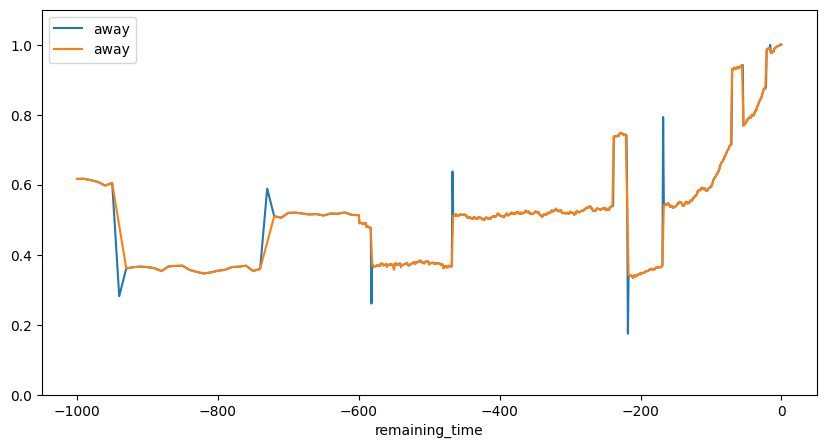

In [93]:
fig, ax = plt.subplots(1, 1, figsize = (10, 5))

# df_real_games_1920\
# .query("period <= 4 & game_id == 41900405")\
# .reset_index(drop = True)\
# .pipe(preenche_dataframe, df_full = df_full)\
# .merge(df_indexador_1819, how = "left")\
# .query("period == 4")\
# [["period", "remaining_time", "dif", "posse", "away", "draw", "home"]]\
# .set_index("remaining_time")[["away"]].plot(ylim = [0, 1.1], ax = ax)

df_real_games_1920\
.query("period <= 4 & game_id == 41900405")\
.reset_index(drop = True)\
.pipe(preenche_dataframe, df_full = df_full)\
.merge(df_indexador_1819, how = "left")\
.query("period == 4 & remaining_time <= 1000")\
.assign(remaining_time = lambda df: -df["remaining_time"])\
[["period", "remaining_time", "dif", "posse", "away", "draw", "home"]]\
.set_index("remaining_time")[["away"]].plot(ylim = [0, 1.1], ax = ax)

df_real_games_1920\
.query("period <= 4 & game_id == 41900405")\
.reset_index(drop = True)\
.pipe(preenche_dataframe, df_full = df_full)\
.merge(df_indexador_1819, how = "left")\
.query("period == 4 & remaining_time <= 1000 & token_obj.isna()")\
.assign(remaining_time = lambda df: -df["remaining_time"])\
[["period", "remaining_time", "dif", "posse", "away", "draw", "home"]]\
.set_index("remaining_time")[["away"]].plot(ylim = [0, 1.1], ax = ax)

# df_real_games_1920\
# .query("period <= 4 & game_id == 41900405")\
# .reset_index(drop = True)\
# .pipe(preenche_dataframe, df_full = df_full)\
# .merge(df_indexador_1819, how = "left")\
# .query("period == 4 & token.isna() & posse == -1")\
# [["period", "remaining_time", "dif", "posse", "away", "draw", "home"]]\
# .set_index("remaining_time")[["away"]].plot(ylim = [0, 1.1], ax = ax)



In [91]:
df_real_games_1920\
.query("period <= 4 & game_id == 41900405")\
.reset_index(drop = True)\
.pipe(preenche_dataframe, df_full = df_full)\
.merge(df_indexador_1819, how = "left")\
.assign(dif_away = lambda df: df["away"] - df["away"].shift(1))\
.query("period == 4 & remaining_time <= 240")\
[["period", "clock", "remaining_time", "home_points", "away_points", "dif", "posse", "token_obj", "away", "draw", "home", "dif_away"]]\
.iloc[:60]

,period,clock,remaining_time,home_points,away_points,dif,posse,token_obj,away,draw,home,dif_away
4803,4,NaN,240,106.0,107.0,-1.0,1.0,NaN,0.538197,0.116738,0.345064,-0.000858
4804,4,00:23:90,239,106.0,107.0,-1.0,1.0,p400_2(5),0.538860,0.116580,0.344560,0.000663
4805,4,NaN,238,106.0,107.0,-1.0,-1.0,NaN,0.737049,0.105965,0.156986,0.198189
4806,4,NaN,237,106.0,107.0,-1.0,-1.0,NaN,0.735569,0.108424,0.156006,-0.001479
4807,4,NaN,236,106.0,107.0,-1.0,-1.0,NaN,0.738449,0.106500,0.155051,0.002880
4808,4,NaN,235,106.0,107.0,-1.0,-1.0,NaN,0.736677,0.105799,0.157524,-0.001772
4809,4,NaN,234,106.0,107.0,-1.0,-1.0,NaN,0.738413,0.105263,0.156324,0.001736
4810,4,NaN,233,106.0,107.0,-1.0,-1.0,NaN,0.740047,0.106167,0.153786,0.001634
4811,4,NaN,232,106.0,107.0,-1.0,-1.0,NaN,0.738619,0.105965,0.155416,-0.001428
4812,4,NaN,231,106.0,107.0,-1.0,-1.0,NaN,0.738753,0.104972,0.156275,0.000134


In [338]:
df_resultados

,game_id,index,period,remaining_time,clock,token,last_time,spent_time,limhfouls,limvfouls,home_points,away_points,dif,ball_possession,step,sim_id,token_,token_obj,tk_simp,min_step,max_step,next_token_obj,last_token_obj,posse,total,ind_turning,away,draw,home,condicao,time,prop_time,hpts,apts,outcome,season,HOME_TEAM,AWAY_TEAM,SEASON_TYPE
0,21900001,0,4,10,NaN,NaN,NaN,NaN,NaN,NaN,117.0,117.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,1322.0,1.0,0.039334,0.954614,0.006051,1,28790,0.999653,117.0,117.0,draw,2019-20,Toronto Raptors,New Orleans Pelicans,Regular Season
1,21900002,0,4,1510,NaN,NaN,NaN,NaN,NaN,NaN,110.0,102.0,8.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,1199.0,1.0,0.030025,0.019183,0.950792,1,27290,0.947569,110.0,102.0,home,2019-20,LA Clippers,Los Angeles Lakers,Regular Season
2,21900003,0,4,44,NaN,NaN,NaN,NaN,NaN,NaN,126.0,125.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1080.0,1.0,0.019444,0.014815,0.965741,1,28756,0.998472,126.0,125.0,home,2019-20,Charlotte Hornets,Chicago Bulls,Regular Season
3,21900004,0,4,970,NaN,NaN,NaN,NaN,NaN,NaN,103.0,110.0,-7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,1168.0,1.0,0.964041,0.014555,0.021404,1,27830,0.966319,103.0,110.0,away,2019-20,Indiana Pacers,Detroit Pistons,Regular Season
4,21900005,0,4,5050,NaN,NaN,NaN,NaN,NaN,NaN,81.0,69.0,12.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1107.0,1.0,0.027100,0.015357,0.957543,1,23750,0.824653,81.0,69.0,home,2019-20,Orlando Magic,Cleveland Cavaliers,Regular Season
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5781,22301226,0,4,1290,NaN,NaN,NaN,NaN,NaN,NaN,112.0,120.0,-8.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,1079.0,1.0,0.973123,0.012975,0.013902,1,27510,0.955208,112.0,120.0,away,2023-24,Portland Trail Blazers,Dallas Mavericks,Regular Season
5782,22301227,0,4,2560,NaN,NaN,NaN,NaN,NaN,NaN,121.0,112.0,9.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1238.0,1.0,0.024233,0.023425,0.952342,1,26240,0.911111,121.0,112.0,home,2023-24,Boston Celtics,New York Knicks,Regular Season
5783,22301228,0,4,1830,NaN,NaN,NaN,NaN,NaN,NaN,98.0,107.0,-9.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,976.0,1.0,0.953893,0.019467,0.026639,1,26970,0.936458,98.0,107.0,away,2023-24,Phoenix Suns,Sacramento Kings,Regular Season
5784,22301229,0,4,584,NaN,NaN,NaN,NaN,NaN,NaN,114.0,119.0,-5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,1391.0,1.0,0.950395,0.029475,0.020129,1,28216,0.979722,114.0,119.0,away,2023-24,Milwaukee Bucks,Indiana Pacers,Regular Season


<Axes: >

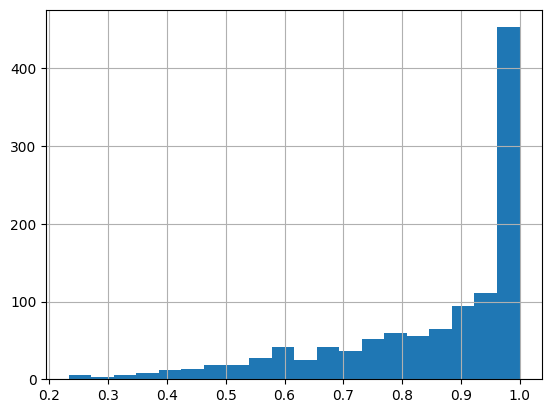

In [259]:
df_turning_points_1920\
.assign(time = lambda df: ((df["period"] - 1) * 7200) + (7200 - df["remaining_time"]))\
.assign(prop_time = lambda df: df["time"] / 28800)\
["prop_time"].hist(bins = 20)

<Axes: >

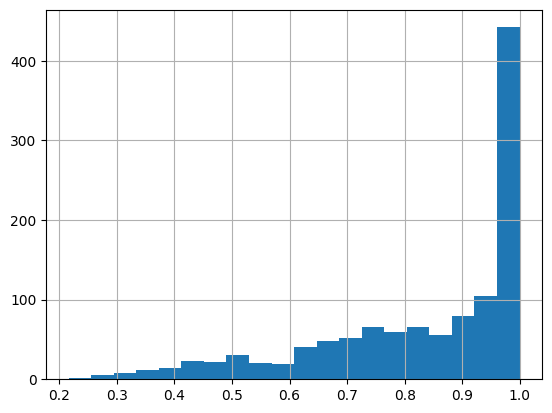

In [260]:
df_turning_points_2021\
.assign(time = lambda df: ((df["period"] - 1) * 7200) + (7200 - df["remaining_time"]))\
.assign(prop_time = lambda df: df["time"] / 28800)\
["prop_time"].hist(bins = 20)

<Axes: >

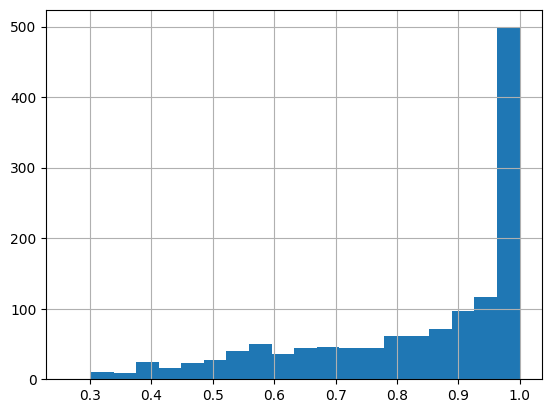

In [261]:
df_turning_points_2122\
.assign(time = lambda df: ((df["period"] - 1) * 7200) + (7200 - df["remaining_time"]))\
.assign(prop_time = lambda df: df["time"] / 28800)\
["prop_time"].hist(bins = 20)

<Axes: >

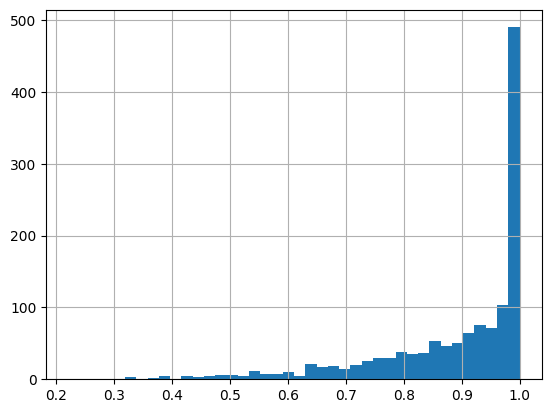

In [339]:
df_turning_points_2223\
.assign(time = lambda df: ((df["period"] - 1) * 7200) + (7200 - df["remaining_time"]))\
.assign(prop_time = lambda df: df["time"] / 28800)\
["prop_time"].hist(bins = 40)

In [69]:
df_turning_points_2324

,game_id,index,period,remaining_time,clock,token,last_time,spent_time,limhfouls,limvfouls,home_points,away_points,dif,ball_possession,step,sim_id,token_,token_obj,tk_simp,min_step,max_step,next_token_obj,last_token_obj,posse,total,ind_turning,away,draw,home,condicao
0,22300001,0,4,103,NaN,NaN,NaN,NaN,NaN,NaN,117.0,114.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1416.0,1.0,0.001412,0.014831,0.983757,1
0,22300002,0,4,87,NaN,NaN,NaN,NaN,NaN,NaN,108.0,105.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1384.0,1.0,0.000723,0.010116,0.989162,1
0,22300003,0,3,710,NaN,NaN,NaN,NaN,NaN,NaN,94.0,79.0,15.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,861.0,1.0,0.034843,0.015099,0.950058,1
0,22300004,0,4,120,00:12:00,539.0,120.0,0.0,0.0,0.0,106.0,109.0,-3.0,-1.0,324.0,22300004.0,p440_8(0)p500_3(22w),p500_3(22w),_3,322.0,324.0,p400_4(0p),p451_6(21p)p500_3(12c),-1.0,1365.0,1.0,0.968498,0.027106,0.004396,1
0,22300005,0,4,8,NaN,NaN,NaN,NaN,NaN,NaN,139.0,139.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,1386.0,1.0,0.043290,0.950216,0.006494,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,22301226,0,4,1290,NaN,NaN,NaN,NaN,NaN,NaN,112.0,120.0,-8.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,1079.0,1.0,0.973123,0.012975,0.013902,1
0,22301227,0,4,2560,NaN,NaN,NaN,NaN,NaN,NaN,121.0,112.0,9.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1238.0,1.0,0.024233,0.023425,0.952342,1
0,22301228,0,4,1830,NaN,NaN,NaN,NaN,NaN,NaN,98.0,107.0,-9.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,976.0,1.0,0.953893,0.019467,0.026639,1
0,22301229,0,4,584,NaN,NaN,NaN,NaN,NaN,NaN,114.0,119.0,-5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,1391.0,1.0,0.950395,0.029475,0.020129,1


<Axes: >

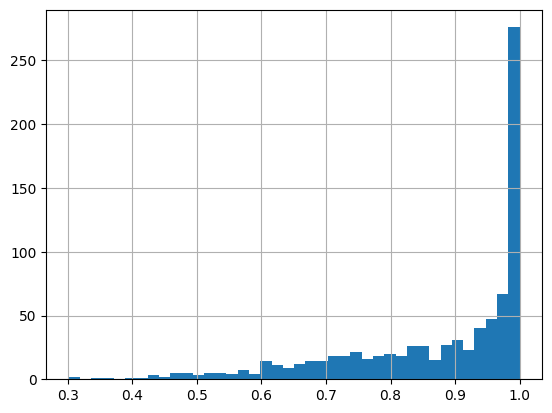

In [340]:
df_turning_points_2324\
.assign(time = lambda df: ((df["period"] - 1) * 7200) + (7200 - df["remaining_time"]))\
.assign(prop_time = lambda df: df["time"] / 28800)\
["prop_time"].hist(bins = 40)

In [337]:
df_resultados = pd.concat(objs = [df_turning_points_1920, df_turning_points_2021, df_turning_points_2122, df_turning_points_2223, df_turning_points_2324], axis = 0)\
.assign(time = lambda df: ((df["period"] - 1) * 7200) + (7200 - df["remaining_time"]))\
.assign(prop_time = lambda df: df["time"] / 28800)\
.assign(hpts = lambda df: df.groupby("game_id")["home_points"].transform("max"))\
.assign(apts = lambda df: df.groupby("game_id")["away_points"].transform("max"))\
.assign(outcome = "draw")\
.assign(outcome = lambda df: np.where(df["hpts"] > df["apts"], "home", df["outcome"]))\
.assign(outcome = lambda df: np.where(df["hpts"] < df["apts"], "away", df["outcome"]))\
.merge(df_games_nba[["game_id", "season", "HOME_TEAM", "AWAY_TEAM", "SEASON_TYPE"]], how = "left")

In [341]:
df_resultados\
.groupby(["outcome", "season"], as_index = False, dropna = False)["prop_time"].describe()

,outcome,season,count,mean,std,min,25%,50%,75%,max
0,away,2019-20,478.0,0.898239,0.119212,0.452431,0.841753,0.955556,0.991337,0.999687
1,away,2020-21,500.0,0.877062,0.139320,0.393750,0.799566,0.933333,0.992370,0.999757
2,away,2021-22,566.0,0.887153,0.134122,0.382292,0.816319,0.943056,0.993490,0.999722
3,away,2022-23,505.0,0.898533,0.126132,0.364236,0.847222,0.946528,0.993681,0.999618
4,away,2023-24,353.0,0.890350,0.129680,0.350347,0.813194,0.953472,0.993125,0.999722
5,draw,2019-20,75.0,0.999703,0.000051,0.999653,0.999653,0.999687,0.999757,0.999757
6,draw,2020-21,58.0,0.999752,0.000050,0.999687,0.999687,0.999792,0.999792,0.999792
7,draw,2021-22,58.0,0.999741,0.000017,0.999722,0.999722,0.999757,0.999757,0.999757
8,draw,2022-23,85.0,0.999701,0.000051,0.999653,0.999653,0.999687,0.999757,0.999757
9,draw,2023-24,41.0,0.999707,0.000017,0.999687,0.999687,0.999722,0.999722,0.999722


In [342]:
df_resultados.query("AWAY_TEAM == 'Los Angeles Lakers' & season == '2019-20'")\
[["game_id", "period", "remaining_time", "dif", "outcome", "away", "draw", "home", "prop_time"]]

,game_id,period,remaining_time,dif,outcome,away,draw,home,prop_time
1,21900002,4,1510,8.0,home,0.030025,0.019183,0.950792,0.947569
73,21900074,4,43,3.0,home,0.004662,0.042735,0.952603,0.998507
87,21900088,4,920,-6.0,away,0.957858,0.016681,0.025461,0.968056
99,21900100,4,2930,-10.0,away,0.950506,0.014623,0.034871,0.898264
150,21900151,4,554,-5.0,away,0.957333,0.017778,0.024889,0.980764
219,21900220,4,27,-3.0,away,0.953993,0.046007,0.000000,0.999062
231,21900232,4,9,-1.0,away,0.953904,0.005644,0.040452,0.999687
248,21900249,4,2250,-12.0,away,0.990510,0.003559,0.005931,0.921875
263,21900264,4,53,-2.0,away,0.968198,0.023852,0.007951,0.998160
303,21900304,4,750,-6.0,away,0.965608,0.013228,0.021164,0.973958


In [343]:
df_resultados\
.assign(team = lambda df: np.where(df["outcome"] == "away", df["HOME_TEAM"], "draw"))\
.assign(team = lambda df: np.where(df["outcome"] == "home", df["AWAY_TEAM"], df["team"]))\
.groupby(["season", "team"], as_index = False, dropna = False)["prop_time"].describe()\
.query("season == '2022-23'")\
.sort_values("mean", ascending = False)

,season,team,count,mean,std,min,25%,50%,75%,max
123,2022-23,draw,85.0,0.999701,0.000051,0.999653,0.999653,0.999687,0.999757,0.999757
98,2022-23,Cleveland Cavaliers,35.0,0.927027,0.112660,0.427083,0.884028,0.975694,0.997396,0.999722
121,2022-23,Utah Jazz,42.0,0.919434,0.108400,0.596181,0.871701,0.969792,0.993073,0.999722
99,2022-23,Dallas Mavericks,41.0,0.910871,0.124262,0.434028,0.875347,0.976042,0.997882,0.999722
113,2022-23,Oklahoma City Thunder,40.0,0.908722,0.110001,0.594097,0.848003,0.946875,0.996675,0.999618
100,2022-23,Denver Nuggets,33.0,0.908476,0.121865,0.441319,0.865278,0.951736,0.996042,0.999757
118,2022-23,Sacramento Kings,38.0,0.908194,0.118705,0.544444,0.835851,0.964583,0.994653,0.999722
112,2022-23,New York Knicks,34.0,0.905943,0.100352,0.660764,0.859983,0.934722,0.989826,0.999618
115,2022-23,Philadelphia 76ers,30.0,0.905603,0.121589,0.510417,0.870573,0.959896,0.978958,0.999618
93,2022-23,Atlanta Hawks,42.0,0.905446,0.109651,0.594444,0.854861,0.951910,0.991189,0.999722


<Axes: ylabel='Density'>

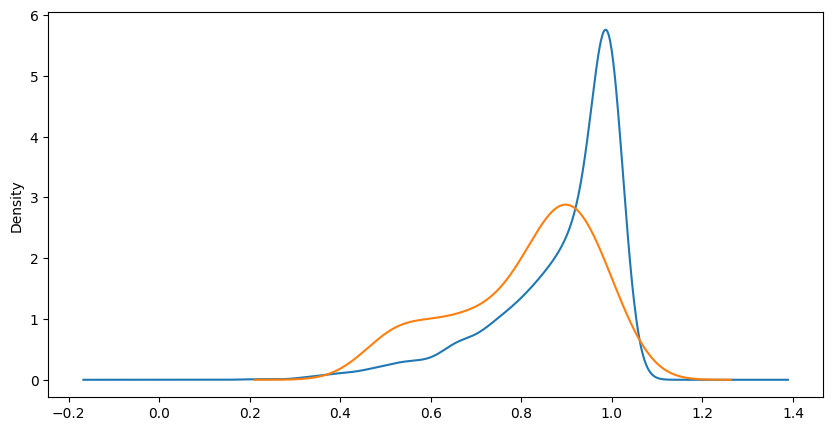

In [347]:
fig, ax = plt.subplots(1, 1, figsize = (10, 5))
df_resultados.query("season == '2022-23'")["prop_time"].plot(kind = "density", ax = ax)

df_resultados\
.assign(team = lambda df: np.where(df["outcome"] == "away", df["HOME_TEAM"], "draw"))\
.assign(team = lambda df: np.where(df["outcome"] == "home", df["AWAY_TEAM"], df["team"]))\
.query("season == '2022-23' & team == 'San Antonio Spurs'")\
["prop_time"].plot(kind = "density", ax = ax)

In [316]:
df_resultados\
.assign(team = lambda df: np.where(df["outcome"] == "away", df["AWAY_TEAM"], "draw"))\
.assign(team = lambda df: np.where(df["outcome"] == "home", df["HOME_TEAM"], df["team"]))\
.groupby(["season", "team"], as_index = False, dropna = False)["prop_time"].describe()\
.query("season == '2022-23'")\
.sort_values("mean", ascending = False)

,season,team,count,mean,std,min,25%,50%,75%,max
123,2022-23,draw,86.0,0.999423,0.000017,0.999410,0.999410,0.999410,0.999444,0.999444
104,2022-23,Indiana Pacers,33.0,0.935556,0.074742,0.706250,0.904861,0.957292,0.996389,0.999444
96,2022-23,Charlotte Hornets,25.0,0.906804,0.153439,0.326389,0.913889,0.973264,0.989410,0.999201
108,2022-23,Miami Heat,54.0,0.902096,0.134854,0.529167,0.872656,0.966319,0.996519,0.999444
121,2022-23,Utah Jazz,32.0,0.891516,0.119585,0.618056,0.831771,0.932292,0.988785,0.999444
103,2022-23,Houston Rockets,21.0,0.890359,0.154522,0.471875,0.842361,0.958681,0.993229,0.999271
114,2022-23,Orlando Magic,33.0,0.881276,0.138940,0.478472,0.805903,0.930208,0.991632,0.999444
119,2022-23,San Antonio Spurs,21.0,0.877252,0.126127,0.540972,0.781597,0.895139,0.983819,0.999201
110,2022-23,Minnesota Timberwolves,42.0,0.869607,0.155742,0.465625,0.816406,0.940104,0.995017,0.999444
101,2022-23,Detroit Pistons,14.0,0.866094,0.167486,0.462847,0.859288,0.924479,0.982639,0.999271


In [329]:
df_resultados\
.assign(cat = "")\
.assign(cat = lambda df: np.where((df["cat"] == "") & (df["prop_time"] <= 0.75), "3. até o fim do terceiro periodo", df["cat"]))\
.assign(cat = lambda df: np.where((df["cat"] == "") & (df["prop_time"] <= 0.875), "4. até a primeira metade do quarto periodo", df["cat"]))\
.assign(cat = lambda df: np.where((df["cat"] == "") & (df["prop_time"] <= 0.9583333), "5. antes dos dois ultimos minutos do quarto periodo", df["cat"]))\
.assign(cat = lambda df: np.where((df["cat"] == "") & (df["prop_time"] <= 0.9791666), "6. antes do ultimo minuto do quarto periodo", df["cat"]))\
.assign(cat = lambda df: np.where((df["cat"] == "") & (df["prop_time"] <= 0.9930556), "7. antes dos ultimos 20secs do quarto periodo", df["cat"]))\
.assign(cat = lambda df: np.where((df["cat"] == "") & (df["prop_time"] <= 0.9965277), "8. antes dos ultimos 10secs do quarto periodo", df["cat"]))\
.assign(cat = lambda df: np.where((df["cat"] == ""), "9. nos ultimos 10secs do quarto periodo", df["cat"]))\
.groupby(["cat", "season"], as_index = False, dropna = False).size()\
.assign(total = lambda df: df.groupby("season")["size"].transform("sum"))\
.assign(prop = lambda df: 100 * df["size"] / df["total"])\
.pivot_table(index = "cat", columns = "season", values = "prop", margins = True)\
.assign(prop_acm = lambda df: df["All"].cumsum())


season,2019-20,2020-21,2021-22,2022-23,2023-24,All,prop_acm
cat,,,,,,,
3. até o fim do terceiro periodo,24.759405,29.487179,28.873772,23.863636,28.674699,27.131738,27.131738
4. até a primeira metade do quarto periodo,16.010499,16.495726,15.495087,17.196970,16.506024,16.340861,43.472599
5. antes dos dois ultimos minutos do quarto periodo,19.072616,15.555556,16.704460,18.409091,17.349398,17.418224,60.890823
6. antes do ultimo minuto do quarto periodo,6.999125,6.581197,7.482993,6.439394,6.144578,6.729457,67.620281
7. antes dos ultimos 20secs do quarto periodo,7.436570,7.435897,8.465608,7.878788,9.156627,8.074698,75.694979
8. antes dos ultimos 10secs do quarto periodo,4.636920,6.666667,4.837491,6.212121,6.626506,5.795941,81.490920
9. nos ultimos 10secs do quarto periodo,21.084864,17.777778,18.140590,20.000000,15.542169,18.509080,100.000000
All,14.285714,14.285714,14.285714,14.285714,14.285714,14.285714,114.285714


In [324]:
df_resultados\
.assign(team = lambda df: np.where(df["outcome"] == "away", df["AWAY_TEAM"], "draw"))\
.assign(team = lambda df: np.where(df["outcome"] == "home", df["HOME_TEAM"], df["team"]))\
.assign(cat = "")\
.assign(cat = lambda df: np.where((df["cat"] == "") & (df["prop_time"] <= 0.75), "3. até o fim do terceiro periodo", df["cat"]))\
.assign(cat = lambda df: np.where((df["cat"] == "") & (df["prop_time"] <= 0.875), "4. até a primeira metade do quarto periodo", df["cat"]))\
.assign(cat = lambda df: np.where((df["cat"] == "") & (df["prop_time"] <= 0.9583333), "5. antes dos dois ultimos minutos do quarto periodo", df["cat"]))\
.assign(cat = lambda df: np.where((df["cat"] == "") & (df["prop_time"] <= 0.9791666), "6. antes do ultimo minuto do quarto periodo", df["cat"]))\
.assign(cat = lambda df: np.where((df["cat"] == "") & (df["prop_time"] <= 0.9930556), "7. antes dos ultimos 20secs do quarto periodo", df["cat"]))\
.assign(cat = lambda df: np.where((df["cat"] == "") & (df["prop_time"] <= 0.9965277), "8. antes dos ultimos 10secs do quarto periodo", df["cat"]))\
.assign(cat = lambda df: np.where((df["cat"] == ""), "9. nos ultimos 10secs do quarto periodo", df["cat"]))\
.groupby(["cat", "season", "team"], as_index = False, dropna = False).size()\
.assign(total = lambda df: df.groupby(["team", "season"])["size"].transform("sum"))\
.assign(prop = lambda df: 100 * df["size"] / df["total"])\
.query("cat.str.contains('^3.')")\
.pivot_table(index = "team", columns = "season", values = "prop")


season,2019-20,2020-21,2021-22,2022-23,2023-24
team,,,,,
Atlanta Hawks,22.222222,34.042553,39.130435,24.390244,15.789474
Boston Celtics,35.714286,31.428571,46.666667,38.095238,33.333333
Brooklyn Nets,25.806452,35.185185,33.333333,27.272727,31.818182
Charlotte Hornets,4.761905,34.482759,31.818182,12.000000,NaN
Chicago Bulls,25.000000,35.483871,17.777778,19.444444,14.285714
Cleveland Cavaliers,25.000000,31.578947,31.707317,37.777778,26.470588
Dallas Mavericks,30.952381,34.090909,31.666667,26.470588,34.375000
Denver Nuggets,13.461538,39.130435,42.222222,32.812500,27.027027
Detroit Pistons,38.888889,31.578947,15.000000,21.428571,14.285714


In [269]:
df_resultados\
.assign(altura_temporada = lambda df: df["game_id"].astype("str").str[3:].astype("int"))\
.assign(ind = lambda df: (df["prop_time"] >= 0.9930))\
.query("season == '2021-22' & SEASON_TYPE == 'Regular Season'")\
.sort_values(["game_id", "altura_temporada"])\
.reset_index(drop = True)\
.reset_index()\
.assign(media = lambda df: df["level_0"].rolling(window = 100, min_periods = 1).mean())

,level_0,game_id,index,period,remaining_time,clock,token,last_time,spent_time,limhfouls,limvfouls,home_points,away_points,dif,ball_possession,step,sim_id,token_,token_obj,tk_simp,min_step,max_step,next_token_obj,last_token_obj,posse,total,ind_turning,away,draw,home,condicao,time,prop_time,hpts,apts,outcome,season,HOME_TEAM,AWAY_TEAM,SEASON_TYPE,altura_temporada,ind,media
0,0,22100001,0,4,5020,NaN,NaN,NaN,NaN,NaN,NaN,103.0,93.0,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,1138.0,1.0,0.075571,0.019332,0.905097,1,23780,0.825694,103.0,93.0,home,2021-22,Milwaukee Bucks,Brooklyn Nets,Regular Season,1,False,0.0
1,1,22100002,0,4,2250,NaN,NaN,NaN,NaN,NaN,NaN,103.0,110.0,-7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,1159.0,1.0,0.909405,0.025884,0.064711,1,26550,0.921875,103.0,110.0,away,2021-22,Los Angeles Lakers,Golden State Warriors,Regular Season,2,False,0.5
2,2,22100003,0,4,18,NaN,NaN,NaN,NaN,NaN,NaN,123.0,122.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,1208.0,1.0,0.087748,0.011589,0.900662,1,28782,0.999375,123.0,122.0,home,2021-22,Charlotte Hornets,Indiana Pacers,Regular Season,3,True,1.0
3,3,22100004,0,4,383,NaN,NaN,NaN,NaN,NaN,NaN,86.0,90.0,-4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1092.0,1.0,0.901099,0.060440,0.038462,1,28417,0.986701,86.0,90.0,away,2021-22,Detroit Pistons,Chicago Bulls,Regular Season,4,False,1.5
4,4,22100005,0,4,60,NaN,NaN,NaN,NaN,NaN,NaN,114.0,113.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1180.0,1.0,0.030508,0.015254,0.954237,1,28740,0.997917,114.0,113.0,home,2021-22,New York Knicks,Boston Celtics,Regular Season,5,True,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1225,1225,22101226,0,4,2550,NaN,NaN,NaN,NaN,NaN,NaN,89.0,82.0,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1242.0,1.0,0.070853,0.027375,0.901771,1,26250,0.911458,89.0,82.0,home,2021-22,New York Knicks,Toronto Raptors,Regular Season,1226,False,1175.5
1226,1226,22101227,0,3,136,NaN,NaN,NaN,NaN,NaN,NaN,99.0,88.0,11.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1091.0,1.0,0.059578,0.017415,0.923006,1,21464,0.745278,99.0,88.0,home,2021-22,Orlando Magic,Miami Heat,Regular Season,1227,False,1176.5
1227,1227,22101228,0,4,3330,NaN,NaN,NaN,NaN,NaN,NaN,106.0,98.0,8.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1213.0,1.0,0.060181,0.019786,0.920033,1,25470,0.884375,106.0,98.0,home,2021-22,Philadelphia 76ers,Detroit Pistons,Regular Season,1228,False,1177.5
1228,1228,22101229,0,4,84,NaN,NaN,NaN,NaN,NaN,NaN,109.0,112.0,-3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,1193.0,1.0,0.975692,0.024308,0.000000,1,28716,0.997083,109.0,112.0,away,2021-22,Phoenix Suns,Sacramento Kings,Regular Season,1229,True,1178.5


In [192]:
df_games_nba.query("season == '2021-22'").sort_values("GAME_DATE")

,game_id,HOME_TEAM_ID,AWAY_TEAM_ID,HOME_TEAM,AWAY_TEAM,GAME_DATE,season,HOME_PTS,AWAY_PTS,SEASON_TYPE
16519,22100001,1610612749,1610612751,Milwaukee Bucks,Brooklyn Nets,2021-10-19,2021-22,127,104,Regular Season
16520,22100002,1610612747,1610612744,Los Angeles Lakers,Golden State Warriors,2021-10-19,2021-22,114,121,Regular Season
16531,22100013,1610612757,1610612758,Portland Trail Blazers,Sacramento Kings,2021-10-20,2021-22,121,124,Regular Season
16530,22100012,1610612756,1610612743,Phoenix Suns,Denver Nuggets,2021-10-20,2021-22,98,110,Regular Season
16529,22100011,1610612762,1610612760,Utah Jazz,Oklahoma City Thunder,2021-10-20,2021-22,107,86,Regular Season
...,...,...,...,...,...,...,...,...,...,...
17831,42100402,1610612744,1610612738,Golden State Warriors,Boston Celtics,2022-06-05,2021-22,107,88,Playoffs
17832,42100403,1610612738,1610612744,Boston Celtics,Golden State Warriors,2022-06-08,2021-22,116,100,Playoffs
17833,42100404,1610612738,1610612744,Boston Celtics,Golden State Warriors,2022-06-10,2021-22,97,107,Playoffs
17834,42100405,1610612744,1610612738,Golden State Warriors,Boston Celtics,2022-06-13,2021-22,104,94,Playoffs


In [348]:
df_resultados.groupby("season")["prop_time"].describe()

,count,mean,std,min,25%,50%,75%,max
season,,,,,,,,
2019-20,1143.0,0.885262,0.143045,0.304167,0.819965,0.953472,0.994861,0.999757
2020-21,1170.0,0.871179,0.150748,0.320833,0.792622,0.934549,0.994991,0.999792
2021-22,1323.0,0.874498,0.147879,0.267014,0.790104,0.939931,0.992969,0.999757
2022-23,1320.0,0.888133,0.138165,0.221528,0.828038,0.942708,0.995278,0.999757
2023-24,830.0,0.872243,0.147439,0.301389,0.780295,0.936285,0.993160,0.999722


In [272]:
2880 * 0.8333

2399.904

In [187]:
2880-2859

21

<Axes: xlabel='altura_temporada'>

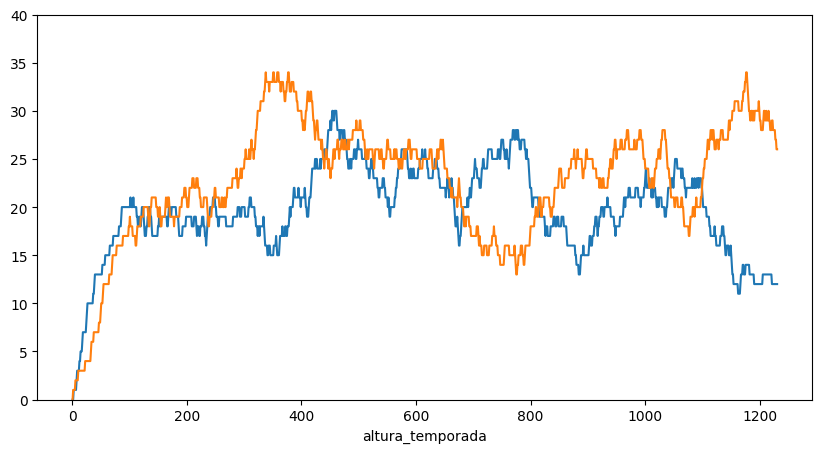

In [334]:
fig, ax = plt.subplots(1, 1, figsize = (10, 5))

df_resultados\
.assign(altura_temporada = lambda df: df["game_id"].astype("str").str[3:].astype("int"))\
.assign(ind = lambda df: (df["prop_time"] >= 0.9965))\
.query("season == '2022-23' & SEASON_TYPE == 'Regular Season'")\
.sort_values(["game_id", "altura_temporada"])\
.assign(media = lambda df: df["ind"].rolling(window = 100, min_periods = 1).sum())\
.set_index("altura_temporada")["media"].plot(ylim = [0.0, 40], ax = ax)

df_resultados\
.assign(altura_temporada = lambda df: df["game_id"].astype("str").str[3:].astype("int"))\
.assign(ind = lambda df: (df["prop_time"] <= 0.75))\
.query("season == '2022-23' & SEASON_TYPE == 'Regular Season'")\
.sort_values(["game_id", "altura_temporada"])\
.assign(media = lambda df: df["ind"].rolling(window = 100, min_periods = 1).sum())\
.set_index("altura_temporada")["media"].plot(ax = ax)

# ax.axhline(100 * 0.5)
# ax.axhline(100 * 0.598)

In [184]:
df_resultados\
.assign(altura_temporada = lambda df: df["game_id"].astype("str").str[3:].astype("int"))\
.query("season == '2022-23' & SEASON_TYPE == 'Regular Season'")\
.query("altura_temporada == 800")

,game_id,index,period,remaining_time,clock,token,last_time,spent_time,limhfouls,limvfouls,home_points,away_points,dif,ball_possession,step,sim_id,token_,token_obj,tk_simp,min_step,max_step,next_token_obj,last_token_obj,posse,total,ind_turning,away,draw,home,condicao,time,prop_time,hpts,apts,outcome,season,HOME_TEAM,AWAY_TEAM,SEASON_TYPE,altura_temporada
4435,22200800,0,4,680,NaN,NaN,NaN,NaN,NaN,NaN,116.0,111.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1451.0,1.0,0.026189,0.019297,0.954514,1,28120,0.976389,116.0,111.0,home,2022-23,Golden State Warriors,Dallas Mavericks,Regular Season,800


In [185]:
df_games_nba.query("game_id == 22200800")

,game_id,HOME_TEAM_ID,AWAY_TEAM_ID,HOME_TEAM,AWAY_TEAM,GAME_DATE,season,HOME_PTS,AWAY_PTS,SEASON_TYPE
18641,22200800,1610612744,1610612742,Golden State Warriors,Dallas Mavericks,2023-02-04,2022-23,119,113,Regular Season


season
2019-20    Axes(0.125,0.11;0.775x0.77)
2020-21    Axes(0.125,0.11;0.775x0.77)
2021-22    Axes(0.125,0.11;0.775x0.77)
2022-23    Axes(0.125,0.11;0.775x0.77)
2023-24    Axes(0.125,0.11;0.775x0.77)
Name: prop_time, dtype: object

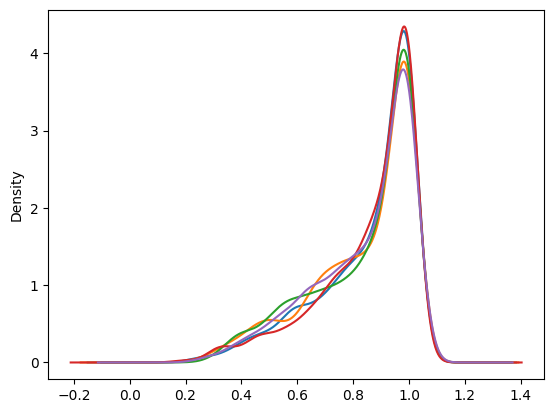

In [274]:
df_resultados\
.groupby(["season"])["prop_time"].plot(kind = "density")

# \
# .query("outcome == 'home'")\
# .groupby(["season", "AWAY_TEAM"])["prop_time"].describe(percentiles = [.01, .05, .1, .25, .5, .75, .9, .95, .99])\
# .sort_values("mean")

season
2019-20    Axes(0.125,0.11;0.775x0.77)
2020-21    Axes(0.125,0.11;0.775x0.77)
2021-22    Axes(0.125,0.11;0.775x0.77)
2022-23    Axes(0.125,0.11;0.775x0.77)
2023-24    Axes(0.125,0.11;0.775x0.77)
Name: prop_time, dtype: object

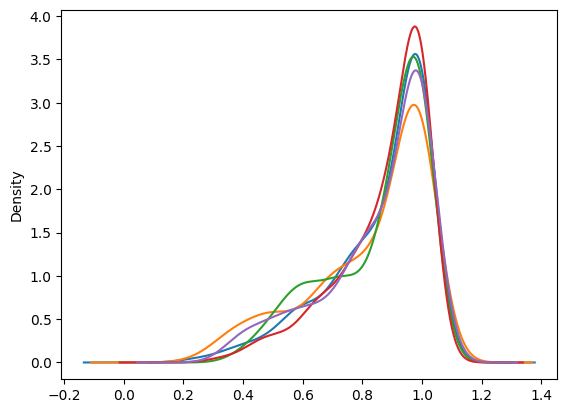

In [275]:
df_resultados\
.query("SEASON_TYPE == 'Regular Season'")\
.assign(altura_temporada = lambda df: df["game_id"].astype("str").str[3:].astype("int"))\
.query("altura_temporada <= 200")\
.groupby(["season"])["prop_time"].plot(kind = "density")


season
2019-20    Axes(0.125,0.11;0.775x0.77)
2020-21    Axes(0.125,0.11;0.775x0.77)
2021-22    Axes(0.125,0.11;0.775x0.77)
2022-23    Axes(0.125,0.11;0.775x0.77)
2023-24    Axes(0.125,0.11;0.775x0.77)
Name: prop_time, dtype: object

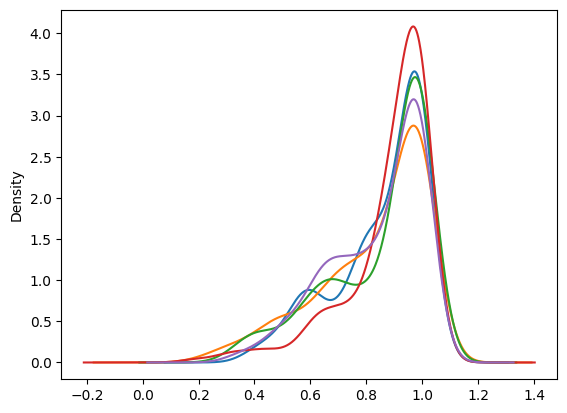

In [276]:
df_resultados\
.query("SEASON_TYPE == 'Regular Season'")\
.assign(altura_temporada = lambda df: df["game_id"].astype("str").str[3:].astype("int"))\
.query("altura_temporada >= 600 & altura_temporada <= 800")\
.groupby(["season"])["prop_time"].plot(kind = "density")

In [277]:
df_resultados\
.query("SEASON_TYPE == 'Regular Season'")\
.assign(altura_temporada = lambda df: df["game_id"].astype("str").str[3:].astype("int"))\
.query("altura_temporada <= 200")\
.groupby(["season"])["prop_time"].describe()

,count,mean,std,min,25%,50%,75%,max
season,,,,,,,,
2019-20,200.0,0.857043,0.168755,0.243889,0.768490,0.937326,0.994939,0.999514
2020-21,200.0,0.825388,0.196560,0.259375,0.698524,0.905035,0.989783,0.999514
2021-22,200.0,0.850216,0.165914,0.388889,0.732005,0.919618,0.992691,0.999549
2022-23,200.0,0.870730,0.150682,0.323958,0.791753,0.924479,0.994635,0.999444
2023-24,200.0,0.849706,0.176597,0.362153,0.767014,0.920486,0.995417,0.999444


In [278]:
df_resultados\
.query("SEASON_TYPE == 'Regular Season'")\
.assign(altura_temporada = lambda df: df["game_id"].astype("str").str[3:].astype("int"))\
.query("altura_temporada >= 600 & altura_temporada <= 800")\
.groupby(["season"])["prop_time"].describe()

,count,mean,std,min,25%,50%,75%,max
season,,,,,,,,
2019-20,200.0,0.851626,0.161171,0.385764,0.773611,0.915278,0.985234,0.999514
2020-21,201.0,0.822356,0.193521,0.216319,0.704861,0.889583,0.992847,0.999514
2021-22,201.0,0.845440,0.183325,0.325347,0.704861,0.941667,0.993854,0.999549
2022-23,201.0,0.878215,0.157349,0.192708,0.846181,0.935417,0.995347,0.999444
2023-24,195.0,0.835087,0.167314,0.344097,0.716146,0.894792,0.980312,0.999444


In [279]:
df_resultados\
.query("SEASON_TYPE == 'Regular Season'")\
.assign(altura_temporada = lambda df: df["game_id"].astype("str").str[3:].astype("int"))\
.query("altura_temporada >= 1000")\
.groupby(["season"])["prop_time"].describe()

,count,mean,std,min,25%,50%,75%,max
season,,,,,,,,
2019-20,88.0,0.863774,0.164551,0.357986,0.749653,0.935243,0.996771,0.999514
2020-21,81.0,0.792729,0.192675,0.360417,0.669444,0.837153,0.982049,0.999514
2021-22,231.0,0.813182,0.200022,0.321528,0.696875,0.872917,0.987795,0.999549
2022-23,231.0,0.842316,0.164836,0.264931,0.744062,0.894444,0.984306,0.999444
2023-24,30.0,0.857016,0.153479,0.429167,0.803906,0.900000,0.972396,0.999375


In [62]:
df_games_nba

,game_id,HOME_TEAM_ID,AWAY_TEAM_ID,HOME_TEAM,AWAY_TEAM,GAME_DATE,season,HOME_PTS,AWAY_PTS
0,20800001,1610612738,1610612739,Boston Celtics,Cleveland Cavaliers,2008-10-28,2008-09,90,85
1,20800002,1610612741,1610612749,Chicago Bulls,Milwaukee Bucks,2008-10-28,2008-09,108,95
2,20800003,1610612747,1610612757,Los Angeles Lakers,Portland Trail Blazers,2008-10-28,2008-09,96,76
3,20800004,1610612753,1610612737,Orlando Magic,Atlanta Hawks,2008-10-29,2008-09,85,99
4,20800005,1610612755,1610612761,Philadelphia 76ers,Toronto Raptors,2008-10-29,2008-09,84,95
...,...,...,...,...,...,...,...,...,...
20003,22301226,1610612757,1610612742,Portland Trail Blazers,Dallas Mavericks,2023-12-08,2023-24,112,125
20004,22301227,1610612738,1610612752,Boston Celtics,New York Knicks,2023-12-08,2023-24,133,123
20005,22301228,1610612756,1610612758,Phoenix Suns,Sacramento Kings,2023-12-08,2023-24,106,114
20006,22301229,1610612749,1610612754,Milwaukee Bucks,Indiana Pacers,2023-12-07,2023-24,119,128


In [58]:
0.936285 * 2880

2696.5008000000003

In [59]:
2696 // 60

44